In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import qstudy as qs
from qstudy import Study
from qstudy.constants import SECTOR_ETF_MAP, SECTOR_ETFS, SP500

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"
SECTOR_CACHE_PATH = Path.home() / ".qstudy" / "sector_map.json"

In [8]:
results = pd.read_csv('../experiments/xsect-mean-rev-cointegration/results.csv', header=0)

In [9]:
results

,Unnamed: 0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10
0,sharpe,0.7994270783456351,0.7298732420396374,0.883049949700467,0.9188957891378204,0.8927919499214523,0.877979698569518,1.0840466431327154,1.138135894329534,1.1895039590991643,1.233631841480957
1,ann_return,0.15244999698328443,0.1390043897149107,0.1755302352849537,0.18225607213092143,0.18504130798150298,0.17551995656596353,0.21367308652732175,0.23781781814664682,0.24724788353298988,0.26496205956863705
2,ann_vol,0.2038140747124074,0.2079188249711315,0.20777937169744734,0.20522910368762196,0.21641053173211164,0.20927098626512045,0.19643368573567074,0.20614274456255624,0.20315097901172502,0.20814406015098694
3,max_drawdown,-0.4357084403865008,-0.29538514581579056,-0.3955913527602436,-0.42077277697601123,-0.42072512198810896,-0.4497389877068627,-0.27902887589755443,-0.3588179366364638,-0.3748609440547155,-0.407276197864456
4,max_drawdown_duration,163,362,357,286,304,296,215,198,158,161
5,max_drawdown_start,2018-07-26 00:00:00,2022-01-05 00:00:00,2022-02-10 00:00:00,2022-03-29 00:00:00,2022-03-28 00:00:00,2022-03-29 00:00:00,2022-01-05 00:00:00,2022-03-30 00:00:00,2022-03-28 00:00:00,2022-03-28 00:00:00
6,max_drawdown_end,2019-03-20 00:00:00,2023-06-14 00:00:00,2023-07-14 00:00:00,2023-05-17 00:00:00,2023-06-12 00:00:00,2023-06-01 00:00:00,2022-11-10 00:00:00,2023-01-11 00:00:00,2022-11-09 00:00:00,2022-11-14 00:00:00
7,avg_daily_turnover,0.4683303886925796,1.2505300353356892,0.9032685512367491,0.9303886925795053,1.152296819787986,1.0016563604240283,0.9303886925795053,1.2317800353356891,1.0958480565371025,1.1597173144876327
8,benchmark_ann_return,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863,0.11777403606105863
9,benchmark_sharpe,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487,0.7063927805820487


In [2]:
def load_universe():
    return qs.download(SP500, START_DATE, END_DATE)

def load_benchmark():
    return qs.download(["SPY"], START_DATE, END_DATE)

def load_sector_factors():
    return qs.download(["SPY", *SECTOR_ETFS], START_DATE, END_DATE)

def load_sector_map():
    if SECTOR_CACHE_PATH.exists():
        with SECTOR_CACHE_PATH.open() as handle:
            cached = json.load(handle)
        return {ticker: cached.get(ticker, "Unknown") for ticker in SP500}
    return qs.get_sector_map(SP500)

def load_sector_etf_by_ticker():
    sector_map = load_sector_map()
    by_ticker = {}
    for ticker in SP500:
        sector = sector_map.get(ticker, "Unknown")
        by_ticker[ticker] = SECTOR_ETF_MAP.get(sector, "SPY")
    return by_ticker

def compute_cointegration_zscore(
    close: pd.DataFrame,
    factor_close: pd.DataFrame,
    *,
    lookback: int = 252,
    z_window: int = 6,
) -> pd.DataFrame:
    log_close = np.log(close.replace(0.0, np.nan))
    available_factor_cols = set(factor_close.columns)
    ticker_to_etf = load_sector_etf_by_ticker()

    sector_close = pd.DataFrame(
        {
            ticker: factor_close[
                ticker_to_etf[ticker] if ticker_to_etf[ticker] in available_factor_cols else "SPY"
            ]
            for ticker in close.columns
        },
        index=close.index,
    )
    sector_log = np.log(sector_close.replace(0.0, np.nan))

    sector_var = sector_log.rolling(lookback).var().replace(0.0, np.nan)
    beta_sector = log_close.rolling(lookback).cov(sector_log).div(sector_var)
    spread = log_close - beta_sector * sector_log

    spread_mean = spread.rolling(z_window).mean()
    spread_std = spread.rolling(z_window).std().replace(0.0, np.nan)
    zscore = spread.sub(spread_mean).div(spread_std)
    return zscore.replace([np.inf, -np.inf], np.nan)


def cointegration_signal(**cache):
    factor_close = load_sector_factors().close.reindex(cache["close"].index)
    zscore = compute_cointegration_zscore(
        cache["close"],
        factor_close,
        lookback=252,
        z_window=6,
    )
    return -zscore


def demean_signal(signal, **cache):
    return signal.sub(signal.mean(axis=1), axis=0)

In [3]:
universe = load_universe()
benchmark = load_benchmark()
factors = load_sector_factors()

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


In [4]:
study = (
    Study(
        universe=universe,
        benchmark=benchmark,
        factors=factors,
        name="xsect_coint_mr_v10_notebook",
    )
    .residualize_returns()
    .base_signal(cointegration_signal)
    .transform_signal(demean_signal)
    .add_tradeable_constraint(qs.min_price(5.0))
    .add_tradeable_constraint(qs.min_adv(5_000_000.0))
    .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
    .build_long_short(n_long=10, n_short=10)
    .rebalance(every=5)
    .run()
)

xsect_coint_mr_v10_notebook:   0%|                                                                                                                 | 0/11 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


xsect_coint_mr_v10_notebook: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.59it/s, stage=metrics]


sharpe                                1.2519
ann_return                          0.265332
ann_vol                             0.204734
max_drawdown                       -0.380623
max_drawdown_duration                    159
max_drawdown_start       2022-03-28 00:00:00
max_drawdown_end         2022-11-10 00:00:00
avg_daily_turnover                  1.158569
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.835515
information_ratio                   1.137994


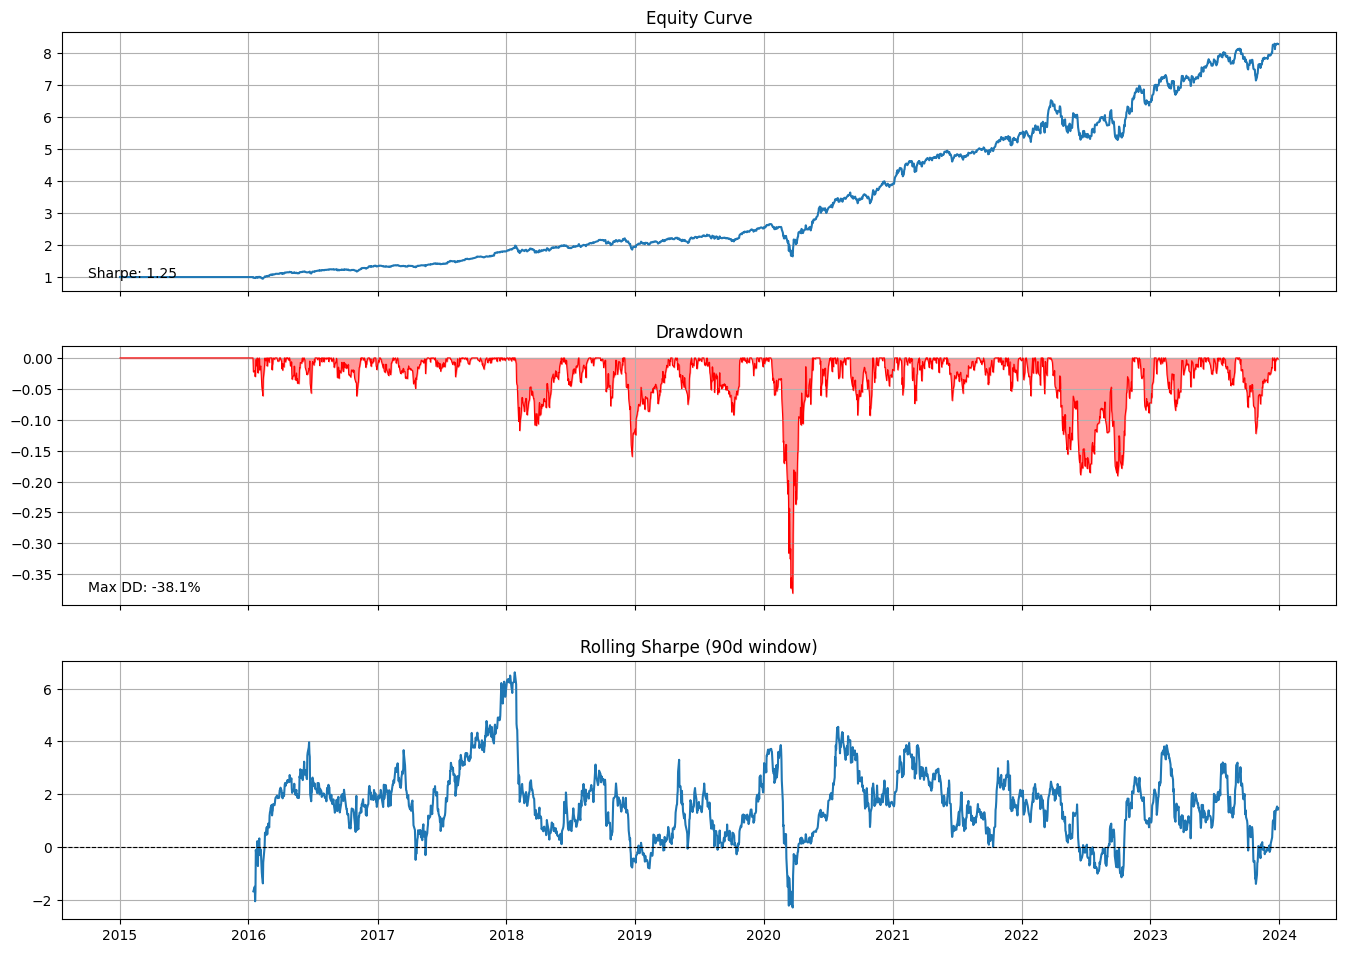

Study(name='xsect_coint_mr_v10_notebook', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler'], weighting=False, ran=True)

In [6]:
study.report()

In [5]:
study.audit()

,step,stage,eligible_tickers,total_notna,nonzero_tickers,abs_sum_mean,net_sum_mean
0,base_signal,signal,461.0,925688.0,NaN,NaN,NaN
1,demean_signal,signal,461.0,925688.0,NaN,NaN,NaN
2,min_price(threshold=5.0),signal,461.0,922853.0,NaN,NaN,NaN
3,min_adv(threshold=5000000),signal,460.0,917916.0,NaN,NaN,NaN
4,liquidity(top_n=150),signal,262.0,300360.0,NaN,NaN,NaN
5,position_builder,position,NaN,NaN,461.0,1.0,1.0
6,rebalance(every=5),position,NaN,NaN,461.0,1.0,1.0


In [10]:
def compute_cointegration_zscore(
    close: pd.DataFrame,
    factor_close: pd.DataFrame,
    *,
    lookback: int = 252,
    z_window: int = 6,
) -> pd.DataFrame:
    log_close = np.log(close.replace(0.0, np.nan))
    available_factor_cols = set(factor_close.columns)
    ticker_to_etf = load_sector_etf_by_ticker()

    sector_close = pd.DataFrame(
        {
            ticker: factor_close[
                ticker_to_etf[ticker] if ticker_to_etf[ticker] in available_factor_cols else "SPY"
            ]
            for ticker in close.columns
        },
        index=close.index,
    )
    sector_log = np.log(sector_close.replace(0.0, np.nan))

    sector_var = sector_log.rolling(lookback).var().replace(0.0, np.nan)
    beta_sector = log_close.rolling(lookback).cov(sector_log).div(sector_var)
    spread = log_close - beta_sector * sector_log

    spread_mean = spread.rolling(z_window).mean()
    spread_std = spread.rolling(z_window).std().replace(0.0, np.nan)
    zscore = spread.sub(spread_mean).div(spread_std)
    return zscore.replace([np.inf, -np.inf], np.nan)


def cointegration_signal(**cache):
    factor_close = load_sector_factors().close.reindex(cache["close"].index)
    zscore = compute_cointegration_zscore(
        cache["close"],
        factor_close,
        lookback=252,
        z_window=6,
    )
    return -zscore

def benchmark_regime_scaler(fast=100, slow=200, defensive_scale=0.8):
    def scaler(positions, **cache):
        benchmark = cache["benchmark"]
        if benchmark is None:
            return positions

        price = (1.0 + benchmark.fillna(0.0)).cumprod()
        fast_ma = price.rolling(fast).mean()
        slow_ma = price.rolling(slow).mean()
        scale = pd.Series(1.0, index=positions.index)
        scale = scale.where(fast_ma >= slow_ma, defensive_scale).shift(1).fillna(1.0)
        return positions.mul(scale, axis=0)

    return scaler


def build_v14_study():
    universe = load_universe()
    benchmark = load_benchmark()
    factors = load_sector_factors()

    return (
        Study(
            universe=universe,
            benchmark=benchmark,
            factors=factors,
            name="xsect_coint_mr_v14_notebook",
        )
        .residualize_returns()
        .base_signal(cointegration_signal)
        .transform_signal(demean_signal)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=10, n_short=10)
        .rebalance(every=10)
        .scale_risk(vol_target=0.16)
        .run()
    )


study = build_v14_study()

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
xsect_coint_mr_v14_notebook:   0%|                                                                                                                 | 0/12 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


xsect_coint_mr_v14_notebook: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 13.44it/s, stage=metrics]


sharpe                              1.211766
ann_return                          0.201748
ann_vol                             0.162631
max_drawdown                       -0.224577
max_drawdown_duration                    280
max_drawdown_start       2018-09-24 00:00:00
max_drawdown_end         2019-11-01 00:00:00
avg_daily_turnover                  1.158569
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                       0.73057
information_ratio                   0.544446


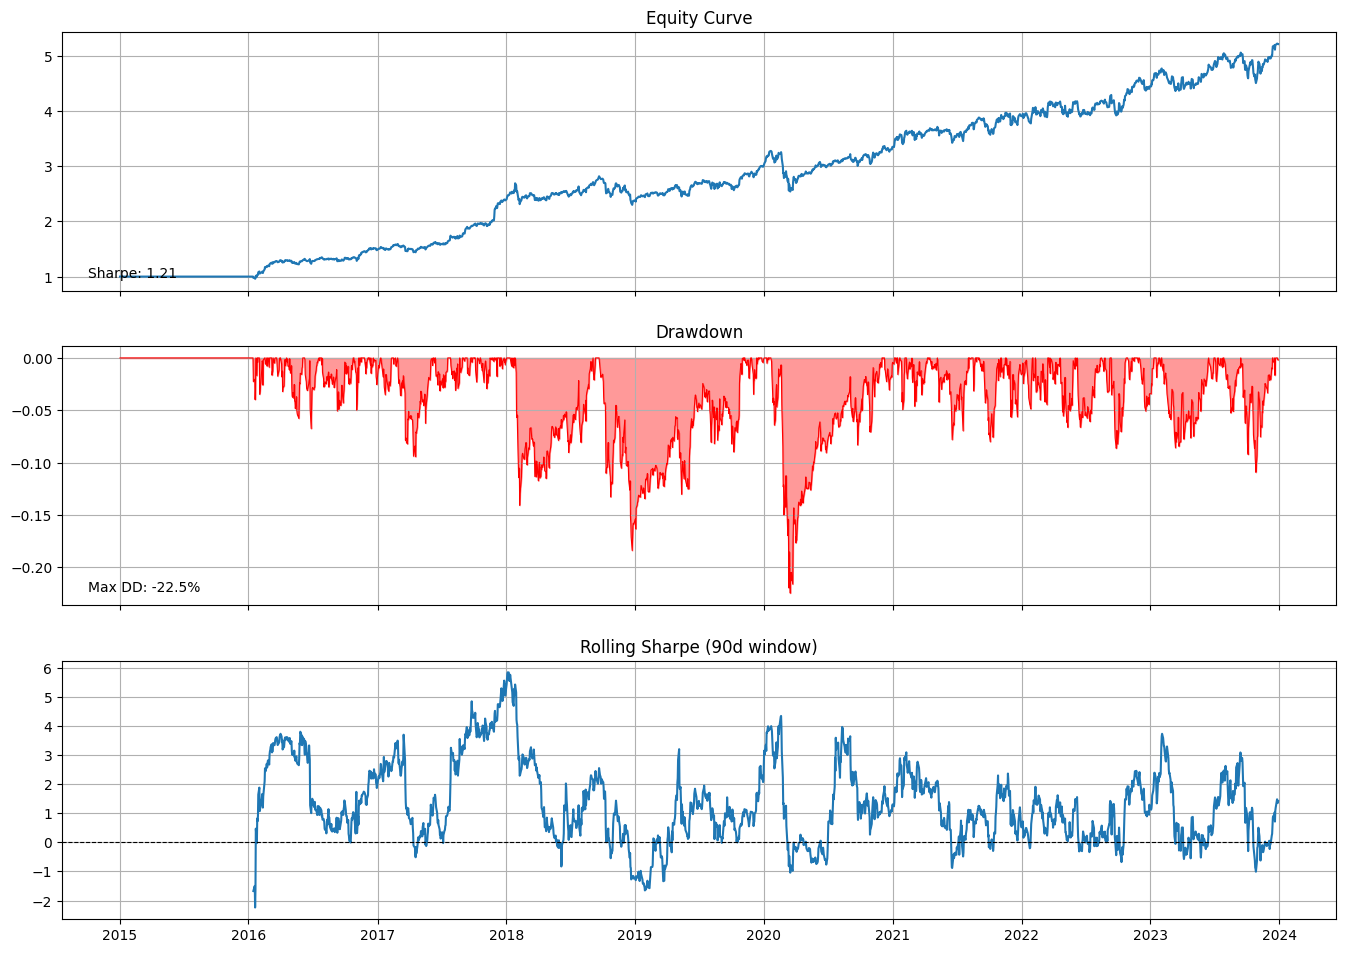

Study(name='xsect_coint_mr_v14_notebook', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=False, ran=True)

In [11]:
study.report()

In [12]:
def compute_cointegration_zscore(
    close: pd.DataFrame,
    factor_close: pd.DataFrame,
    *,
    lookback: int = 252,
    z_window: int = 7,
) -> pd.DataFrame:
    log_close = np.log(close.replace(0.0, np.nan))
    available_factor_cols = set(factor_close.columns)
    ticker_to_etf = load_sector_etf_by_ticker()

    sector_close = pd.DataFrame(
        {
            ticker: factor_close[
                ticker_to_etf[ticker] if ticker_to_etf[ticker] in available_factor_cols else "SPY"
            ]
            for ticker in close.columns
        },
        index=close.index,
    )
    sector_log = np.log(sector_close.replace(0.0, np.nan))

    sector_var = sector_log.rolling(lookback).var().replace(0.0, np.nan)
    beta_sector = log_close.rolling(lookback).cov(sector_log).div(sector_var)
    spread = log_close - beta_sector * sector_log

    spread_mean = spread.rolling(z_window).mean()
    spread_std = spread.rolling(z_window).std().replace(0.0, np.nan)
    zscore = spread.sub(spread_mean).div(spread_std)
    return zscore.replace([np.inf, -np.inf], np.nan)


def cointegration_signal(**cache):
    factor_close = load_sector_factors().close.reindex(cache["close"].index)
    zscore = compute_cointegration_zscore(
        cache["close"],
        factor_close,
        lookback=252,
        z_window=7,
    )
    return -zscore


def build_v20_study():
    universe = load_universe()
    benchmark = load_benchmark()
    factors = load_sector_factors()

    return (
        Study(
            universe=universe,
            benchmark=benchmark,
            factors=factors,
            name="xsect_coint_mr_v20_notebook",
        )
        .residualize_returns()
        .base_signal(cointegration_signal)
        .transform_signal(demean_signal)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=125, window=60))
        .build_long_short(n_long=10, n_short=10)
        .rebalance(every=10)
        .weight_equal_vol(vol_window=60)
        .run()
    )


study = build_v20_study()

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
xsect_coint_mr_v20_notebook:   0%|                                                                                                                 | 0/12 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...


xsect_coint_mr_v20_notebook: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 12.23it/s, stage=metrics]


sharpe                              1.020235
ann_return                           0.18986
ann_vol                              0.18766
max_drawdown                       -0.273955
max_drawdown_duration                    121
max_drawdown_start       2018-01-29 00:00:00
max_drawdown_end         2018-07-20 00:00:00
avg_daily_turnover                  0.975088
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706394
benchmark_corr                      0.851517
information_ratio                   0.632576


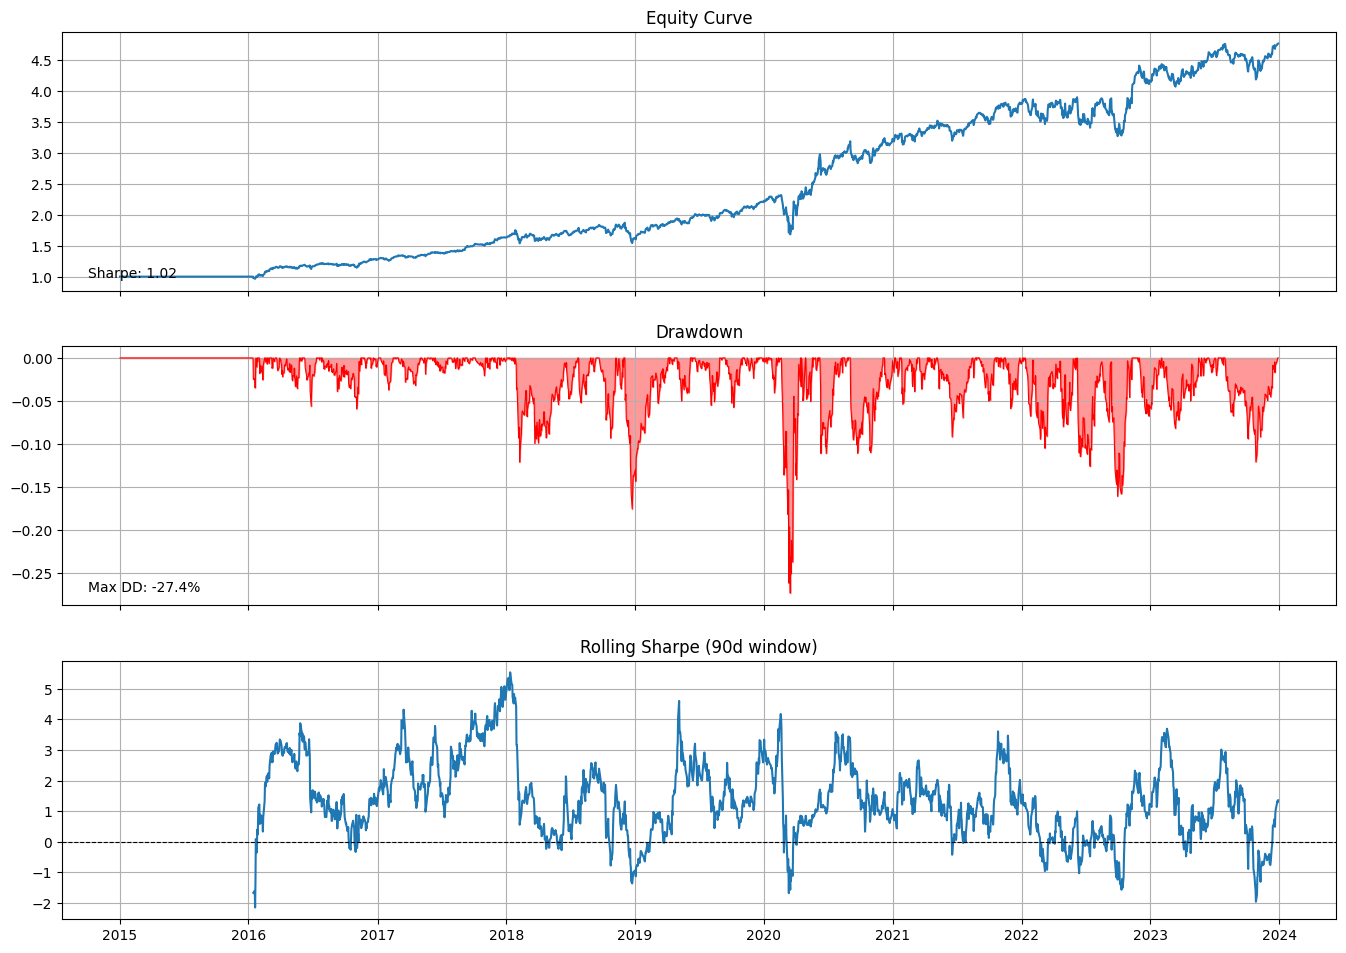

Study(name='xsect_coint_mr_v20_notebook', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler'], weighting=True, ran=True)

In [13]:
study.report()

In [14]:
def load_sector_returns_by_ticker():
    factors = load_sector_factors()
    ticker_to_etf = load_sector_etf_by_ticker()
    available_factor_cols = set(factors.returns.columns)
    return pd.DataFrame(
        {
            ticker: factors.returns[
                ticker_to_etf[ticker] if ticker_to_etf[ticker] in available_factor_cols else "SPY"
            ]
            for ticker in load_universe().returns.columns
        },
        index=factors.returns.index,
    )

def compute_two_factor_residual_zscore(
    returns: pd.DataFrame,
    benchmark_returns: pd.Series,
    sector_returns: pd.DataFrame,
    *,
    beta_window: int = 126,
    signal_window: int = 8,
    clip: float = 3.0,
) -> pd.DataFrame:
    market = pd.DataFrame(
        np.repeat(benchmark_returns.to_numpy()[:, None], returns.shape[1], axis=1),
        index=returns.index,
        columns=returns.columns,
    )
    sector = sector_returns.reindex_like(returns).fillna(0.0)

    market_var = market.rolling(beta_window).var().replace(0.0, np.nan)
    stock_market_beta = returns.rolling(beta_window).cov(market).div(market_var)
    sector_market_beta = sector.rolling(beta_window).cov(market).div(market_var)

    stock_ex_market = returns - stock_market_beta.mul(market)
    sector_ex_market = sector - sector_market_beta.mul(market)
    sector_var = sector_ex_market.rolling(beta_window).var().replace(0.0, np.nan)
    sector_beta = stock_ex_market.rolling(beta_window).cov(sector_ex_market).div(sector_var)

    residual_returns = stock_ex_market - sector_beta.mul(sector_ex_market)
    residual_signal = residual_returns.rolling(signal_window).sum()
    signal_mean = residual_signal.rolling(signal_window).mean()
    signal_std = residual_signal.rolling(signal_window).std().replace(0.0, np.nan)
    zscore = residual_signal.sub(signal_mean).div(signal_std)
    return zscore.clip(-clip, clip).replace([np.inf, -np.inf], np.nan)


def residual_signal(**cache):
    benchmark_returns = load_benchmark().returns["SPY"].reindex(cache["returns"].index).fillna(0.0)
    sector_returns = load_sector_returns_by_ticker().reindex_like(cache["returns"]).fillna(0.0)
    zscore = compute_two_factor_residual_zscore(
        cache["returns"],
        benchmark_returns,
        sector_returns,
        beta_window=126,
        signal_window=8,
    )
    return -zscore


def sector_demean_signal(signal, **cache):
    adjusted = signal.copy()
    sector_map = load_sector_map()
    sector_members = {}
    for ticker, sector in sector_map.items():
        sector_members.setdefault(sector, []).append(ticker)

    for members in sector_members.values():
        cols = [ticker for ticker in members if ticker in adjusted.columns]
        if not cols:
            continue
        adjusted.loc[:, cols] = adjusted[cols].sub(adjusted[cols].mean(axis=1), axis=0)
    return adjusted


def beta_neutralize_positions(window=20):
    def scaler(positions, **cache):
        returns = cache["returns"]
        benchmark = cache["benchmark"]
        if benchmark is None:
            return positions

        bench = benchmark.reindex(returns.index).fillna(0.0)
        mean_r = returns.rolling(window).mean()
        mean_b = bench.rolling(window).mean()
        mean_rb = returns.mul(bench, axis=0).rolling(window).mean()
        cov = mean_rb.sub(mean_r.mul(mean_b, axis=0))
        var_b = bench.rolling(window).var().replace(0.0, np.nan)
        betas = cov.div(var_b, axis=0).shift(1)

        adjusted = positions.copy()
        for date in positions.index:
            active = positions.loc[date]
            active = active[active != 0.0]
            if active.empty:
                continue

            beta_slice = betas.loc[date, active.index].dropna()
            if len(beta_slice) < 2:
                continue

            weights = active.reindex(beta_slice.index)
            beta_exposure = float((weights * beta_slice).sum())
            beta_norm = float((beta_slice**2).sum())
            if beta_norm == 0.0:
                continue

            neutralized = weights - (beta_exposure / beta_norm) * beta_slice
            gross = neutralized.abs().sum()
            if gross == 0.0 or pd.isna(gross):
                continue
            adjusted.loc[date, beta_slice.index] = neutralized / gross

        return adjusted.fillna(0.0)

    scaler.__name__ = f"beta_neutralize_positions_{window}"
    return scaler


def build_v28_study():
    universe = load_universe()
    benchmark = load_benchmark()
    factors = load_sector_factors()

    return (
        Study(
            universe=universe,
            benchmark=benchmark,
            factors=factors,
            name="xsect_coint_mr_v28_notebook",
        )
        .base_signal(residual_signal)
        .transform_signal(demean_signal)
        .transform_signal(sector_demean_signal)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=10, n_short=10)
        .rebalance(every=10)
        .scale_risk(beta_neutralize_positions(20))
        .weight_equal_vol(vol_window=60)
        .run()
    )


study = build_v28_study()

$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
xsect_coint_mr_v28_notebook:   7%|███████▎                                                                                               | 1/14 [00:00<00:00, 3666.35it/s, stage=base_signal]$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 14

In [22]:
 
study = (
        Study(
            universe=universe,
            benchmark=benchmark,
            factors=factors,
            name="xsect_coint_mr_v28_notebook",
        )
        .base_signal(residual_signal)
        .transform_signal(demean_signal)
        .transform_signal(sector_demean_signal)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=10, n_short=10)
        .rebalance(every=10)
        .scale_risk(beta_neutralize_positions(20))
        .weight_equal_vol(vol_window=60)
        .run()
    )


study = build_v28_study()

xsect_coint_mr_v28_notebook:   7%|███████▎                                                                                               | 1/14 [00:00<00:00, 3276.80it/s, stage=base_signal]$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
xsect_coint_mr_v28_notebook: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:18<00:00,  1.35s/it, stage=metrics]
$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn

sharpe                              1.492496
ann_return                          0.199003
ann_vol                             0.127035
max_drawdown                       -0.143272
max_drawdown_duration                    157
max_drawdown_start       2022-12-01 00:00:00
max_drawdown_end         2023-07-19 00:00:00
avg_daily_turnover                  1.206537
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                       0.47607
information_ratio                   0.376211


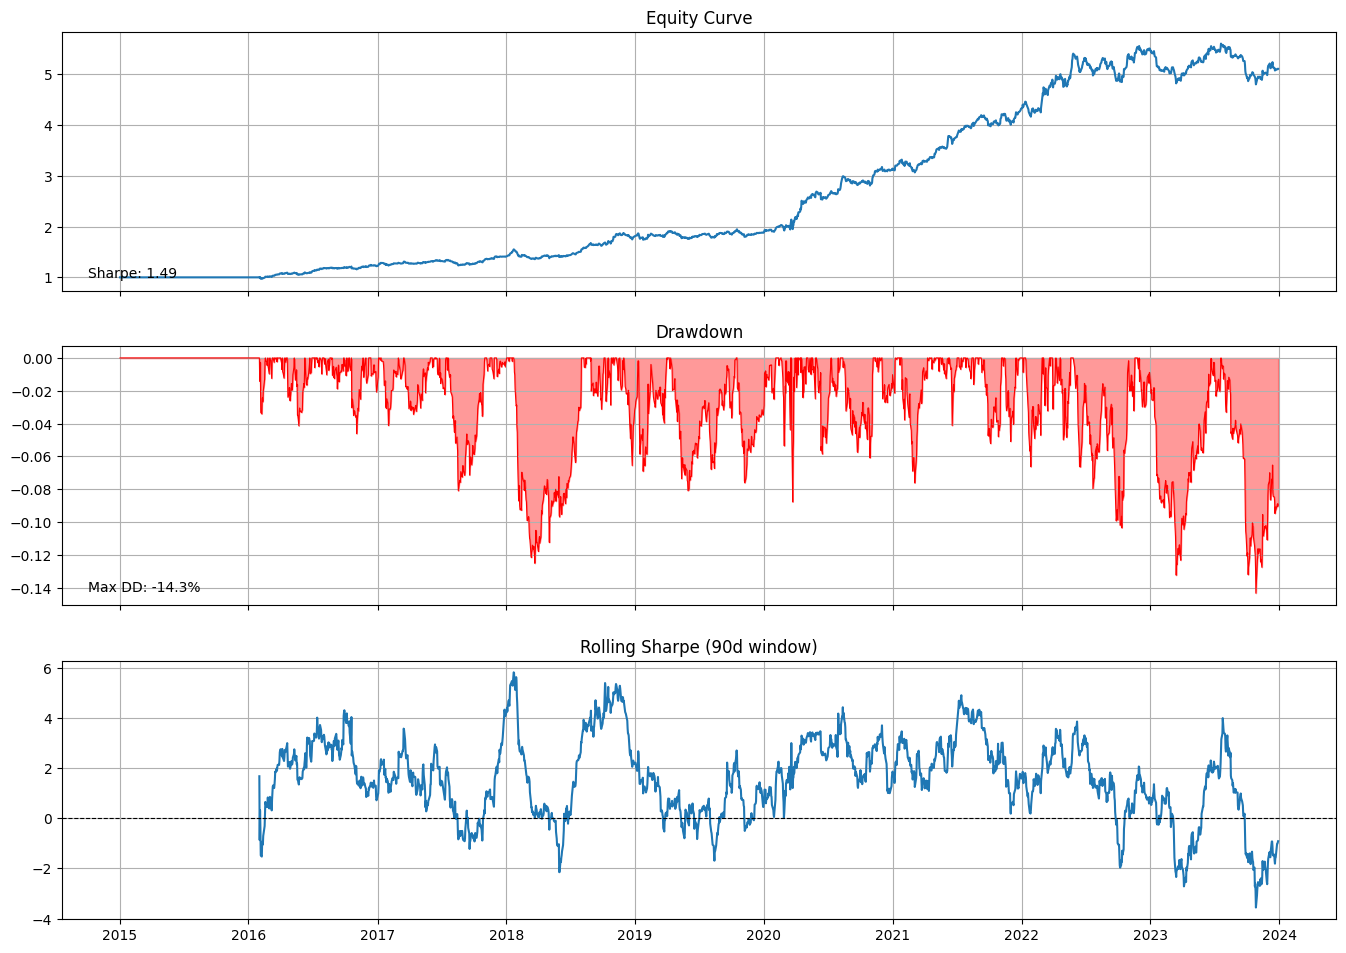

Study(name='xsect_coint_mr_v28_notebook', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=True, ran=True)

In [23]:
study.report()

sharpe                              1.471332
ann_return                          0.195744
ann_vol                             0.127009
max_drawdown                       -0.143273
max_drawdown_duration                    157
max_drawdown_start       2022-12-01 00:00:00
max_drawdown_end         2023-07-19 00:00:00
avg_daily_turnover                   1.20689
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.476739
information_ratio                    0.35983


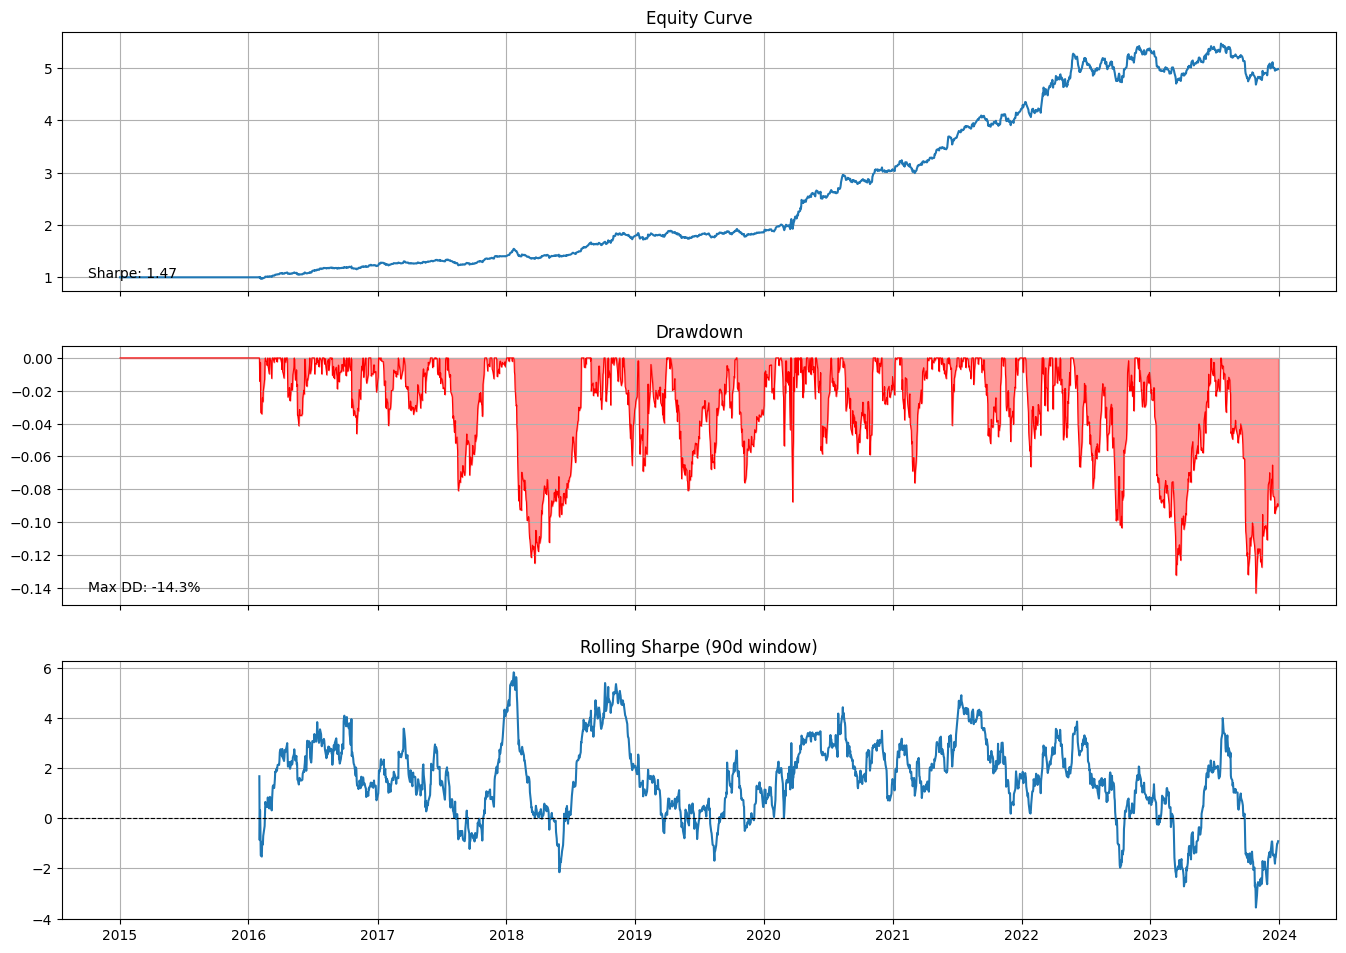

Study(name='xsect_coint_mr_v28_notebook', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler'], weighting=True, ran=True)

In [15]:
study.report()